In [1]:
cd "C:\Users\Lenovo\Desktop\github projects\telcos customer churn"

C:\Users\Lenovo\Desktop\github projects\telcos customer churn


In [2]:
## merging  all algo results into 1 file
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
ml_report = pd.read_csv("reports/model_training_report.csv")
ann_report = pd.read_csv("reports/ann_model_report.csv")

print("ML Models:", ml_report.shape)
print("ANN Report:", ann_report.shape)

ML Models: (8, 9)
ANN Report: (1, 7)


In [4]:
master_report=pd.concat([ml_report,ann_report],ignore_index=True)
master_report

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time (Seconds),AUC ROC RABK,Accuracy_Rank
0,Gradient Boosting,0.7779,0.5738,0.6337,0.6023,0.8430,7.124,1.0,3.0
1,Logistic Regression,0.7459,0.5138,0.7941,0.6239,0.8402,0.173,2.0,5.0
2,CatBoost,0.7864,0.6052,0.5615,0.5825,0.8369,15.825,3.0,1.0
3,LightGBM,0.7857,0.5957,0.5989,0.5973,0.8358,0.481,4.0,2.0
4,Random Forest,0.7779,0.5874,0.5481,0.5671,0.8214,5.991,5.0,3.0
5,XGBoost,0.7644,0.5603,0.5214,0.5402,0.8098,0.692,6.0,4.0
6,KNN,0.6891,0.4456,0.7005,0.5447,0.7623,0.014,7.0,7.0
7,Decision Tree,0.7147,0.4668,0.5267,0.4950,0.6544,0.252,8.0,6.0
8,ANN,0.7587,0.5320,0.7567,0.6247,0.8245,76.330,NaN,NaN


In [5]:
## add ranking column
master_report["ROC AUC Rank"] = (master_report["ROC AUC"].rank(method="dense", ascending=False).astype(int))

master_report["Recall Rank"] = (master_report["Recall"].rank(method="dense", ascending=False).astype(int))

In [6]:
master_report

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time (Seconds),AUC ROC RABK,Accuracy_Rank,ROC AUC Rank,Recall Rank
0,Gradient Boosting,0.7779,0.5738,0.6337,0.6023,0.8430,7.124,1.0,3.0,1,4
1,Logistic Regression,0.7459,0.5138,0.7941,0.6239,0.8402,0.173,2.0,5.0,2,1
2,CatBoost,0.7864,0.6052,0.5615,0.5825,0.8369,15.825,3.0,1.0,3,6
3,LightGBM,0.7857,0.5957,0.5989,0.5973,0.8358,0.481,4.0,2.0,4,5
4,Random Forest,0.7779,0.5874,0.5481,0.5671,0.8214,5.991,5.0,3.0,6,7
5,XGBoost,0.7644,0.5603,0.5214,0.5402,0.8098,0.692,6.0,4.0,7,9
6,KNN,0.6891,0.4456,0.7005,0.5447,0.7623,0.014,7.0,7.0,8,3
7,Decision Tree,0.7147,0.4668,0.5267,0.4950,0.6544,0.252,8.0,6.0,9,8
8,ANN,0.7587,0.5320,0.7567,0.6247,0.8245,76.330,NaN,NaN,5,2


In [7]:
master_report = master_report.sort_values(by="ROC AUC",ascending=False).reset_index(drop=True)

master_report

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time (Seconds),AUC ROC RABK,Accuracy_Rank,ROC AUC Rank,Recall Rank
0,Gradient Boosting,0.7779,0.5738,0.6337,0.6023,0.8430,7.124,1.0,3.0,1,4
1,Logistic Regression,0.7459,0.5138,0.7941,0.6239,0.8402,0.173,2.0,5.0,2,1
2,CatBoost,0.7864,0.6052,0.5615,0.5825,0.8369,15.825,3.0,1.0,3,6
3,LightGBM,0.7857,0.5957,0.5989,0.5973,0.8358,0.481,4.0,2.0,4,5
4,ANN,0.7587,0.5320,0.7567,0.6247,0.8245,76.330,NaN,NaN,5,2
5,Random Forest,0.7779,0.5874,0.5481,0.5671,0.8214,5.991,5.0,3.0,6,7
6,XGBoost,0.7644,0.5603,0.5214,0.5402,0.8098,0.692,6.0,4.0,7,9
7,KNN,0.6891,0.4456,0.7005,0.5447,0.7623,0.014,7.0,7.0,8,3
8,Decision Tree,0.7147,0.4668,0.5267,0.4950,0.6544,0.252,8.0,6.0,9,8


In [8]:
#save file 

master_report.to_csv( "reports/master_model_report.csv",index=False)

# create comparision chart 


#### ROC-AUC COMPARISION

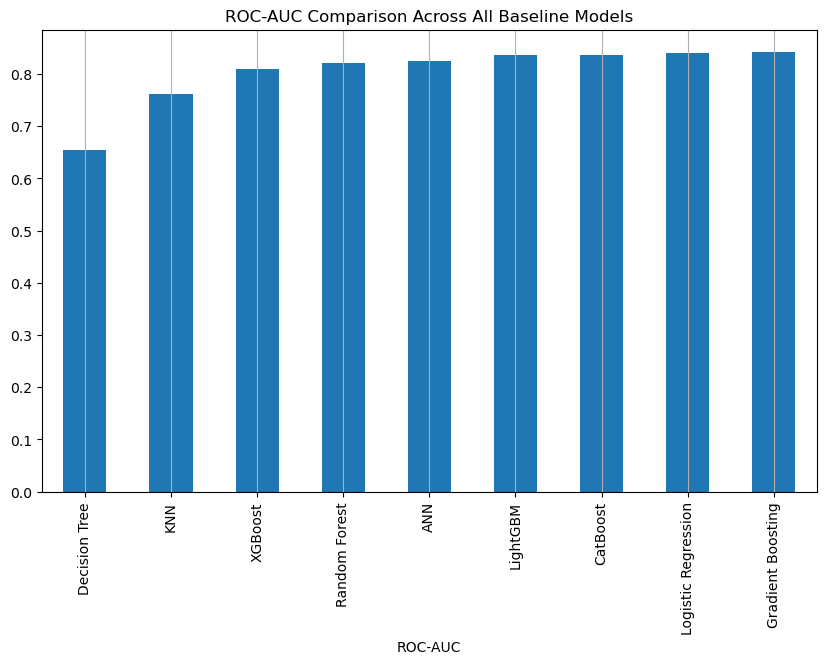

In [9]:
master_report.sort_values("ROC AUC").plot(x="Model",y="ROC AUC",kind="bar",figsize=(10,6),legend=False)

plt.title("ROC-AUC Comparison Across All Baseline Models")
plt.xlabel("ROC-AUC")
plt.grid(axis="x")
plt.show()

#### Recall Comparision

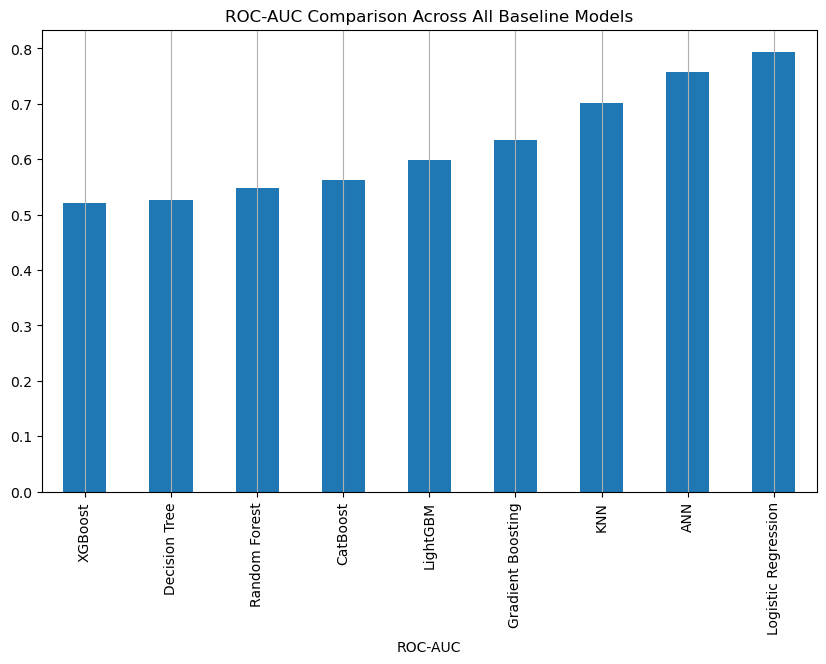

In [10]:
master_report.sort_values("Recall").plot(x="Model",y="Recall",kind="bar",figsize=(10,6),legend=False)

plt.title("ROC-AUC Comparison Across All Baseline Models")
plt.xlabel("ROC-AUC")
plt.grid(axis="x")
plt.show()

#### F1 Score Comparision

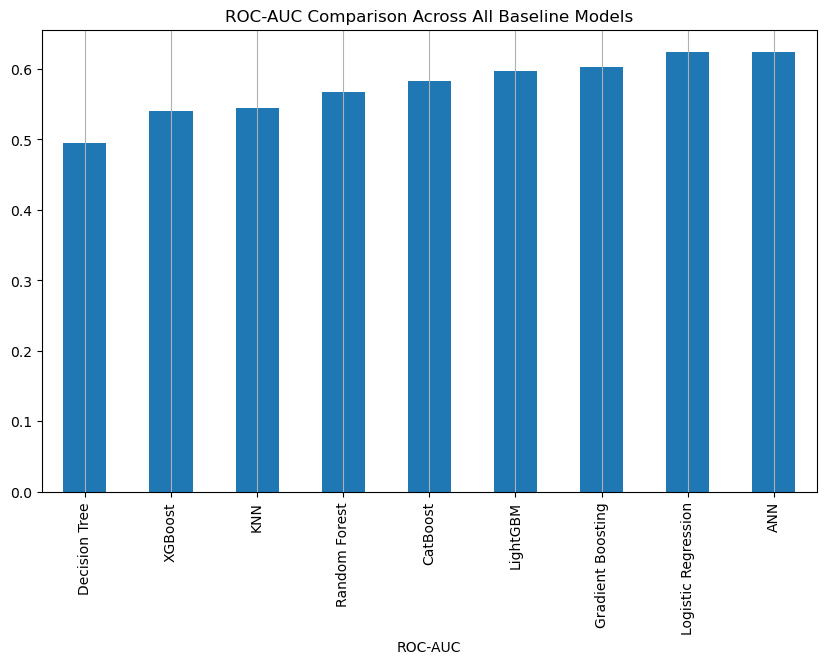

In [11]:
master_report.sort_values("F1 Score").plot(x="Model",y="F1 Score",kind="bar",figsize=(10,6),legend=False)

plt.title("ROC-AUC Comparison Across All Baseline Models")
plt.xlabel("ROC-AUC")
plt.grid(axis="x")
plt.show()

#### Accuracy Comparision

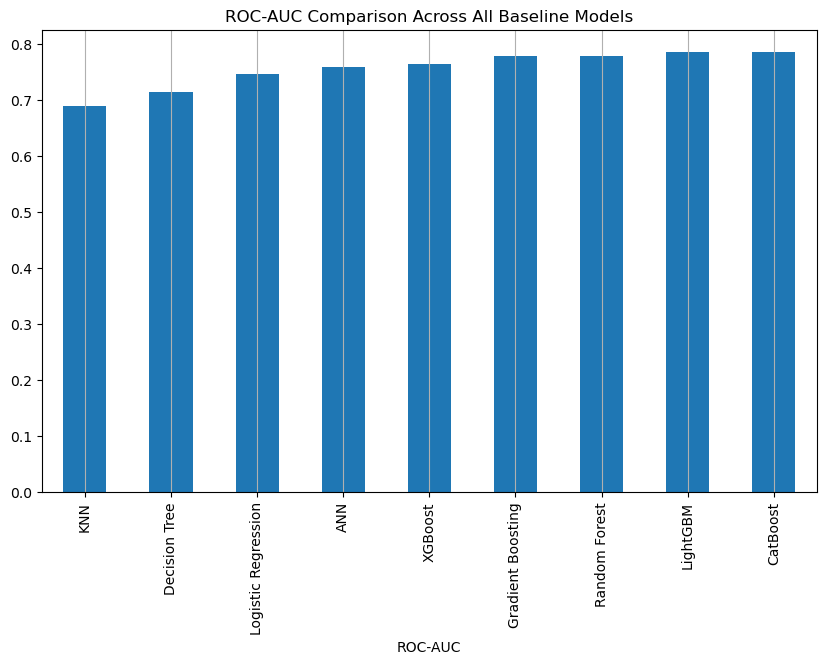

In [12]:
master_report.sort_values("Accuracy").plot(x="Model",y="Accuracy",kind="bar",figsize=(10,6),legend=False)

plt.title("ROC-AUC Comparison Across All Baseline Models")
plt.xlabel("ROC-AUC")
plt.grid(axis="x")
plt.show()

#### Training Time Comparision

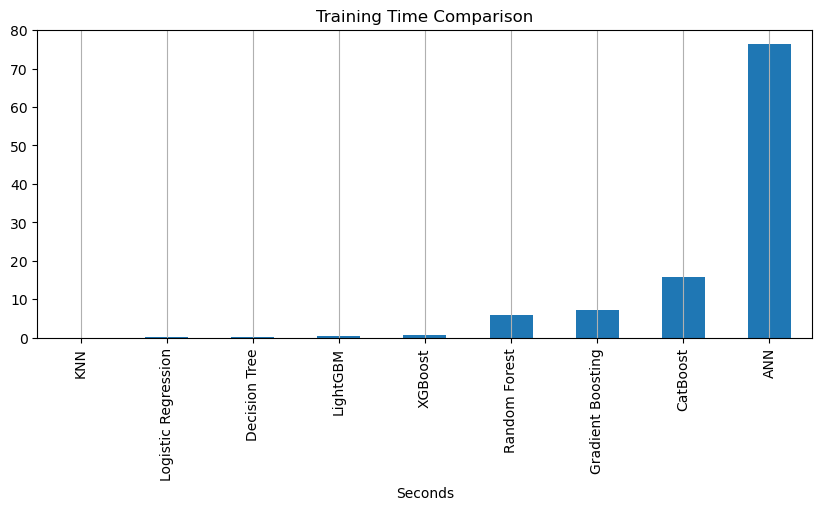

In [13]:
master_report.sort_values("Training Time (Seconds)").plot(x="Model",y="Training Time (Seconds)",kind="bar",figsize=(10,4),legend=False)

plt.title("Training Time Comparison")
plt.xlabel("Seconds")
plt.grid(axis="x")
plt.show()

In [14]:
summary_columns = ["Model","Accuracy","Precision","Recall","F1 Score","ROC AUC","Training Time (Seconds)","ROC AUC Rank","Recall Rank"]

master_report[summary_columns]

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time (Seconds),ROC AUC Rank,Recall Rank
0,Gradient Boosting,0.7779,0.5738,0.6337,0.6023,0.8430,7.124,1,4
1,Logistic Regression,0.7459,0.5138,0.7941,0.6239,0.8402,0.173,2,1
2,CatBoost,0.7864,0.6052,0.5615,0.5825,0.8369,15.825,3,6
3,LightGBM,0.7857,0.5957,0.5989,0.5973,0.8358,0.481,4,5
4,ANN,0.7587,0.5320,0.7567,0.6247,0.8245,76.330,5,2
5,Random Forest,0.7779,0.5874,0.5481,0.5671,0.8214,5.991,6,7
6,XGBoost,0.7644,0.5603,0.5214,0.5402,0.8098,0.692,7,9
7,KNN,0.6891,0.4456,0.7005,0.5447,0.7623,0.014,8,3
8,Decision Tree,0.7147,0.4668,0.5267,0.4950,0.6544,0.252,9,8
